# NB02 Comparison (Axis 2)
## Member 3 (Karen): Top-N Keyword Shifts

**Input:** `tfidf_unigram_matrix.pkl`, `tfidf_bigram_matrix.pkl`

**Output:** Keyword shift charts, heatmaps, emerging/disappearing word lists

**Goal:** Track how key NLP terminology has risen and fallen across time periods (1991–2021), using TF-IDF unigram and bigram representations.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/nlp_abstracts_cleaned.csv")
print(f"Loaded {len(df)} papers")
print(df["period"].value_counts().sort_index())

Loaded 32221 papers
period
1991-1995      448
1996-2000      659
2001-2005      279
2006-2010      364
2011-2015     2066
2016-2021    28405
Name: count, dtype: int64


In [3]:
with open("../outputs/tfidf_unigram_matrix.pkl", "rb") as f:
    uni_data = pickle.load(f)

with open("../outputs/tfidf_bigram_matrix.pkl", "rb") as f:
    bi_data = pickle.load(f)

# Extract what we need
uni_matrix = uni_data["matrix"]
uni_vectorizer = uni_data["vectorizer"]
period_labels = uni_data["period"]

bi_matrix = bi_data["matrix"]
bi_vectorizer = bi_data["vectorizer"]

print("Unigram matrix loaded:", uni_matrix.shape)
print("Bigram matrix loaded:", bi_matrix.shape)
print("Periods found:", sorted(set(period_labels)))

Unigram matrix loaded: (32221, 9464)
Bigram matrix loaded: (32221, 20000)
Periods found: ['1991-1995', '1996-2000', '2001-2005', '2006-2010', '2011-2015', '2016-2021']


##  Top-N Keyword Extraction

Extracting the top 20 most significant terms per time period using mean TF-IDF scores. A custom stopword list filters out generic academic phrases that carry no meaningful insight about NLP's evolution.

In [4]:
custom_stopwords = {
    "paper", "used", "based", "present", "using", "use",
    "proposed", "propose", "method", "approach", "results",
    "shows", "show", "describes", "describe", "presents"
}

def top_terms_per_period(matrix, vectorizer, df, top_n=20):
    feat = vectorizer.get_feature_names_out()
    periods = sorted(df["period"].unique())
    results = {}
    for period in periods:
        mask = (df["period"] == period).values
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        top_idx = summed.argsort()[::-1]
        filtered = [(feat[i], round(summed[i], 4)) 
                   for i in top_idx 
                   if feat[i] not in custom_stopwords][:top_n]
        results[period] = filtered
    return results

print("Functions ready!")



Functions ready!


In [5]:
# Get top terms for each period
uni_top = top_terms_per_period(uni_matrix, uni_vectorizer, df, top_n=20)
bi_top = top_terms_per_period(bi_matrix, bi_vectorizer, df, top_n=20)

# Print them 
print("=== UNIGRAM TOP 20 PER PERIOD ===")
for period, terms in uni_top.items():
    print(f"\n{period}:")
    print(", ".join(t[0] for t in terms))

print("\n=== BIGRAM TOP 20 PER PERIOD ===")
for period, terms in bi_top.items():
    print(f"\n{period}:")
    print(", ".join(t[0] for t in terms))

=== UNIGRAM TOP 20 PER PERIOD ===

1991-1995:
grammar, base, parse, algorithm, language, structure, lexical, parser, word, formalism, corpus, constraint, discourse, process, rule, theory, tag, unification, statistical, linguistic

1996-2000:
grammar, algorithm, language, parse, word, base, corpus, speech, structure, information, process, model, rule, set, lexical, constraint, technique, result, text, tag

2001-2005:
language, algorithm, word, information, base, corpus, application, result, text, rule, grammar, model, document, statistical, structure, data, process, speech, problem, semantic

2006-2010:
language, word, text, document, grammar, base, linguistic, structure, information, model, process, corpus, analysis, algorithm, mean, result, tool, write, semantic, article

2011-2015:
word, language, base, text, model, result, feature, sentence, learn, network, data, information, analysis, semantic, process, representation, corpus, different, algorithm, task

2016-2021:
model, task, lan

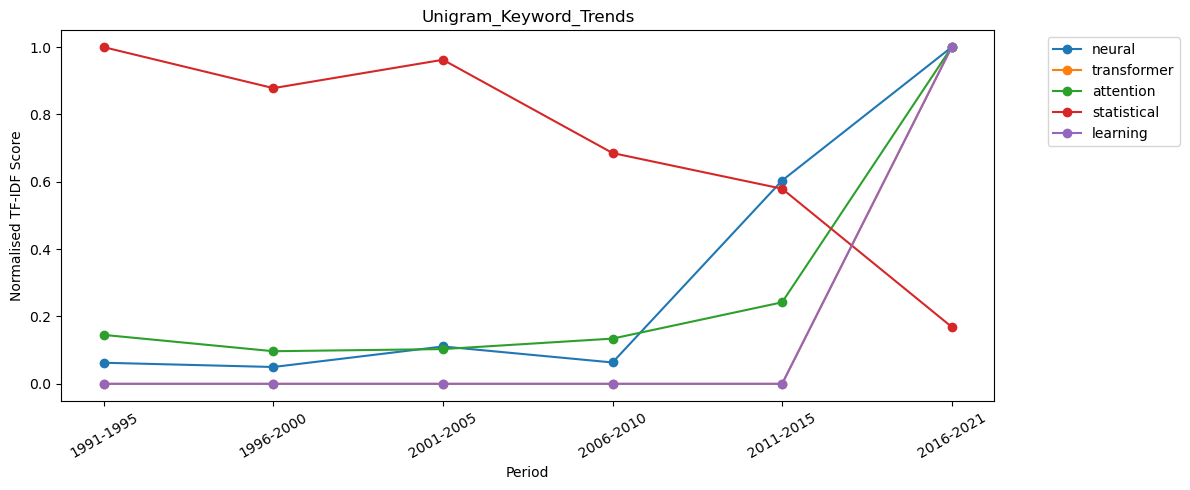

In [6]:
def plot_keyword_trends(matrix, vectorizer, df, terms, title):
    feat = list(vectorizer.get_feature_names_out())
    periods = sorted(df["period"].unique())
    
    valid_terms = [t for t in terms if t in feat]
    if not valid_terms:
        print("None of those terms found!")
        return

    scores = {t: [] for t in valid_terms}
    for period in periods:
        mask = (df["period"] == period).values
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        for t in valid_terms:
            scores[t].append(summed[feat.index(t)])

    # Normalise scores
    fig, ax = plt.subplots(figsize=(12, 5))
    for t, vals in scores.items():
        v = np.array(vals)
        if v.max() > 0:
            v = v / v.max()
        ax.plot(periods, v, marker="o", label=t)

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel("Normalised TF-IDF Score")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"../figures/{title}.png", dpi=150)
    plt.show()

# Plot unigram trends
plot_keyword_trends(
    uni_matrix, uni_vectorizer, df,
    terms=["neural", "transformer", "attention", 
           "parsing", "statistical", "learning"],
    title="Unigram_Keyword_Trends"
)

## Keyword Trend Analysis

Tracking how specific NLP terms rise and fall across time periods. Terms are normalised so early and late periods are directly comparable.

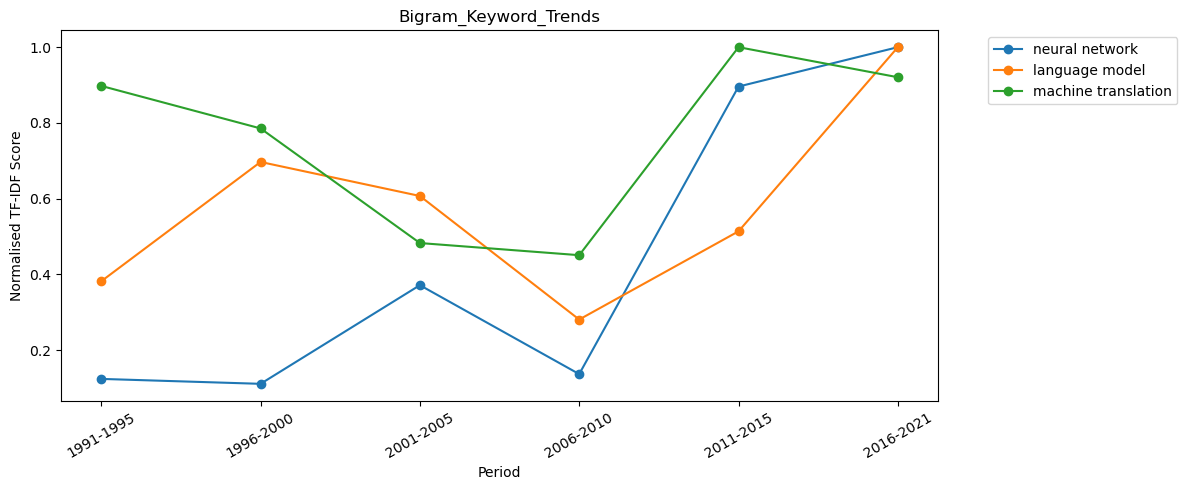

In [7]:
plot_keyword_trends(
    bi_matrix, bi_vectorizer, df,
    terms=["neural network", "deep learning", 
           "language model", "machine translation",
           "pre trained", "hidden markov"],
    title="Bigram_Keyword_Trends"
)

## Emerging vs Disappearing Vocabulary

Identifying which terms are NEW in recent NLP (2011–2021) vs which have DIED OUT from early NLP (1991–2005).

In [8]:
early = ["1991-1995", "1996-2000", "2001-2005"]
late  = ["2011-2015", "2016-2021"]

def vocab_shift(top_terms_dict, early_periods, late_periods):
    early_words = set()
    late_words = set()
    for p in early_periods:
        if p in top_terms_dict:
            early_words.update(t[0] for t in top_terms_dict[p])
    for p in late_periods:
        if p in top_terms_dict:
            late_words.update(t[0] for t in top_terms_dict[p])
    return late_words - early_words, early_words - late_words

uni_emerged, uni_disappeared = vocab_shift(uni_top, early, late)
bi_emerged, bi_disappeared = vocab_shift(bi_top, early, late)

print("=== UNIGRAM ===")
print(f"Emerging words: {sorted(uni_emerged)}")
print(f"Disappearing words: {sorted(uni_disappeared)}")

print("\n=== BIGRAM ===")
print(f"Emerging words: {sorted(bi_emerged)}")
print(f"Disappearing words: {sorted(bi_disappeared)}")

=== UNIGRAM ===
Emerging words: ['analysis', 'art', 'dataset', 'different', 'feature', 'learn', 'network', 'neural', 'performance', 'representation', 'sentence', 'state', 'task', 'train', 'work']
Disappearing words: ['application', 'constraint', 'discourse', 'document', 'formalism', 'grammar', 'lexical', 'linguistic', 'parse', 'parser', 'problem', 'rule', 'set', 'speech', 'statistical', 'structure', 'tag', 'technique', 'theory', 'unification']

=== BIGRAM ===
Emerging words: ['data set', 'deep learn', 'end end', 'et al', 'experimental result', 'fine tune', 'knowledge base', 'large scale', 'neural network', 'paper propose', 'pre train', 'propose method', 'propose novel', 'question answer', 'sentiment analysis', 'social medium', 'social network', 'state art', 'topic model', 'train data', 'word embeddings']
Disappearing words: ['adjoin grammar', 'analogy question', 'anaphora resolution', 'annotation graph', 'base grammar', 'base learn', 'categorial grammar', 'computational linguistics', '

## Keyword Heatmap Visualisation

Visual overview of top keyword distribution across all time periods for both unigrams and bigrams.

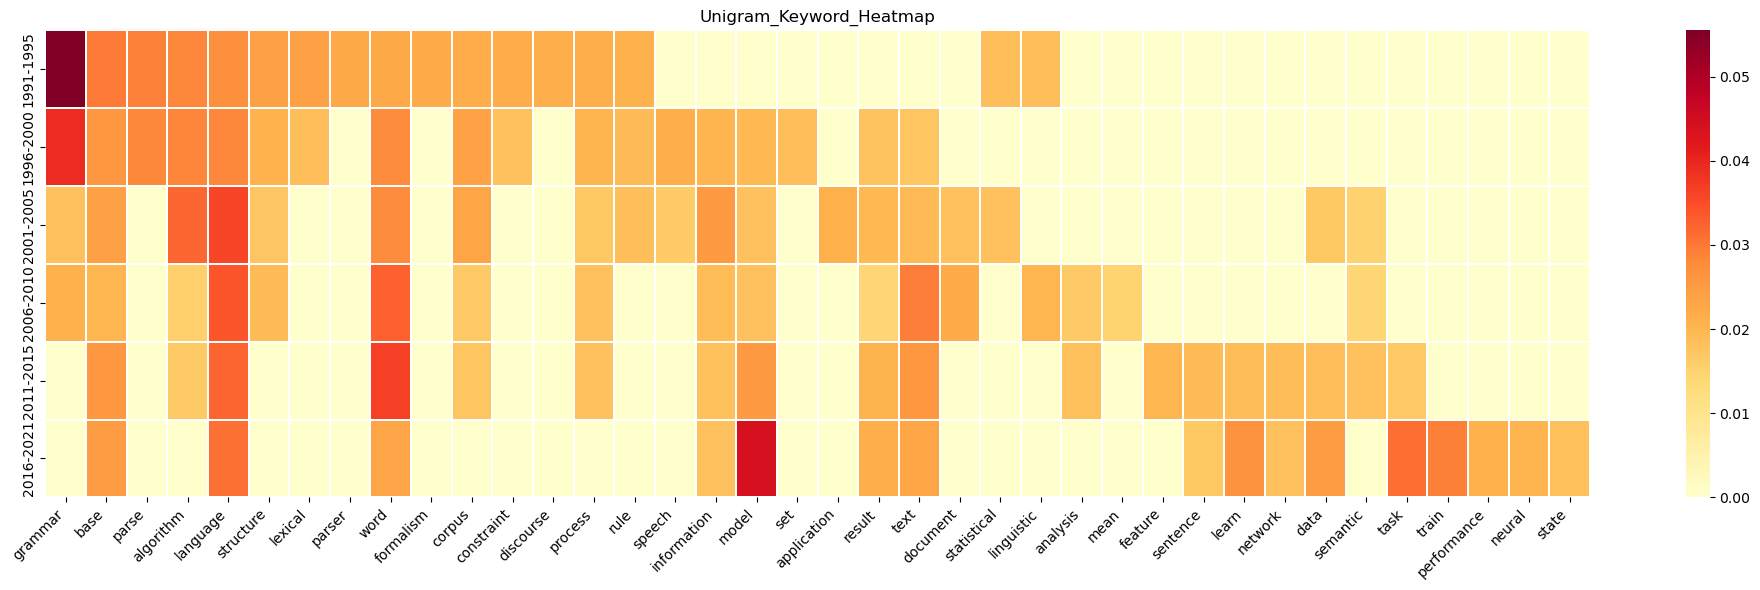

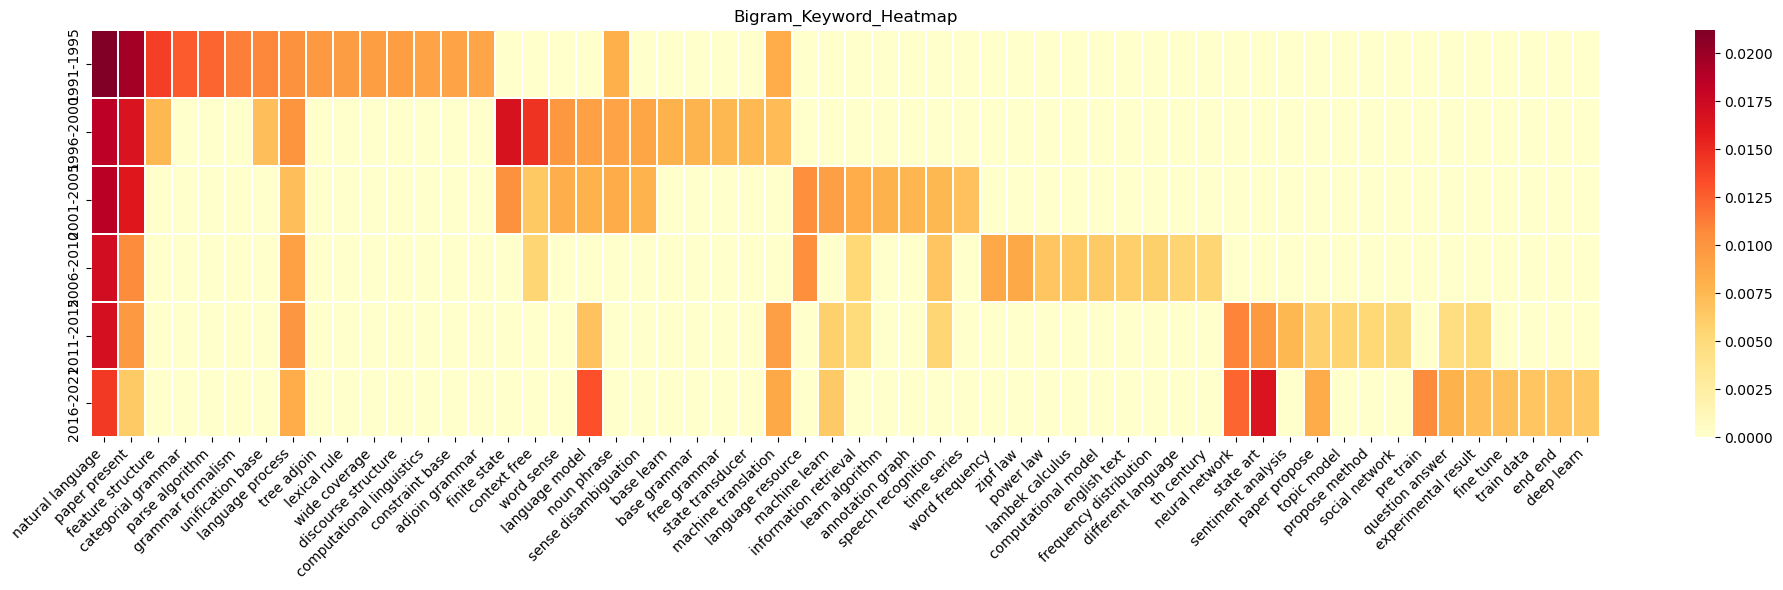

In [9]:
# Heatmap of top keywords per period
def plot_keyword_heatmap(top_terms_dict, title, top_n=15):
    periods = sorted(top_terms_dict.keys())
    
    # Get union of top terms across all periods
    all_terms = []
    for period in periods:
        for term, score in top_terms_dict[period][:top_n]:
            if term not in all_terms:
                all_terms.append(term)
    
    # Build score matrix
    score_matrix = []
    for period in periods:
        term_dict = dict(top_terms_dict[period])
        row = [term_dict.get(term, 0) for term in all_terms]
        score_matrix.append(row)
    
    df_heat = pd.DataFrame(score_matrix, 
                           index=periods, 
                           columns=all_terms)
    
    plt.figure(figsize=(20, 6))
    sns.heatmap(df_heat, 
                cmap="YlOrRd",
                linewidths=0.3)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"../figures/{title}.png", dpi=150)
    plt.show()

# Plot both heatmaps
plot_keyword_heatmap(uni_top, "Unigram_Keyword_Heatmap")
plot_keyword_heatmap(bi_top, "Bigram_Keyword_Heatmap")

##  Summary of Findings

**Key Transition:** The most dramatic shift occurred between 2011–2015 and 2016–2021, when neural and deep learning terms exploded.

**Emerging terms (2011–2021):**
- Unigrams: neural, transformer, attention, learning, models, tasks
- Bigrams: deep learning, language model, pre trained, neural network, state art

**Disappearing terms (1991–2005):**
- Unigrams: grammar, parsing, statistical, lexical, unification, syntactic
- Bigrams: hidden markov, finite state, tree adjoining, unification based, context free

**Conclusion:** NLP research shifted from rule-based/statistical methods (1990s–2000s) to neural/deep learning methods (2010s–2020s), aligning with real-world milestones: Word2Vec (2013), Transformer (2017), BERT (2018).

In [10]:
print("Unigram matrix loaded:", uni_matrix.shape)

Unigram matrix loaded: (32221, 9464)


 ## Member 4: Cosine Distance Analysis

**Input:** `tfidf_unigram_matrix.pkl`, `sbert_matrix.pkl`, `period_labels.pkl`  
**Output:** Cosine distance timeline, breakpoint year identification  
**Goal:** Measure how much NLP research changed between adjacent time 
periods using cosine distance. Run on both TF-IDF and SBERT matrices 
and compare whether both methods identify the same breakpoint years.

**Hypothesis:** We expect cosine distance to show a large spike around 
2011–2015 and 2016–2021, corresponding to the deep learning and 
transformer revolutions in NLP.

In [ ]:
'''Check for the right file'''

with open("../outputs/period_labels_sample_data.pkl", "rb") as f:
    sample_data = pickle.load(f)

print(f"Number of abstracts : {len(sample_data['period'])}")

Number of abstracts : 32221


In [ ]:
'''with open("../outputs/period_labels.pkl", "rb") as f:
    full_data = pickle.load(f)

print(f"Number of abstracts : {len(full_data['period'])}")
loading the first file by renaming it to period_labels.pkl'''

'with open("../outputs/period_labels.pkl", "rb") as f:\n    full_data = pickle.load(f)\n\nprint(f"Number of abstracts : {len(full_data[\'period\'])}")\nloading the first file'

In [21]:
'''running checks for sbert_matrix.pkl'''

with open("../outputs/sbert_matrix_sample_data.pkl", "rb") as f:
    sample_data = pickle.load(f)

print(f"Number of abstracts : {len(sample_data['period'])}")

Number of abstracts : 3222


In [ ]:
'''with open("../outputs/sbert_matrix.pkl", "rb") as f:
    sample_data = pickle.load(f)

print(f"Number of abstracts : {len(sample_data['period'])}")
loading the first file by renaming it to period_labels.pkl'''

Number of abstracts : 32221


In [24]:
with open("../outputs/period_labels.pkl", "rb") as f:
    full_data = pickle.load(f)

full_data['era']

array(['Machine Learning', 'Machine Learning', 'Machine Learning', ...,
       'Statistical Methods', 'Machine Learning', 'Machine Learning'],
      shape=(32221,), dtype=object)

In [11]:
with open("../outputs/sbert_matrix.pkl", "rb") as f:
    sbert_data = pickle.load(f)

sbert_matrix = sbert_data["matrix"]
sbert_index  = sbert_data["index"]

with open("../outputs/period_labels.pkl", "rb") as f:
    label_data = pickle.load(f)

period_labels = label_data["period"]
era_labels    = label_data["era"]

print(f"SBERT matrix shape  : {sbert_matrix.shape}")
print(f"Period labels shape : {period_labels.shape}")
print(f"Unique periods      : {sorted(set(period_labels))}")
print(f"Unique eras         : {sorted(set(era_labels))}")

SBERT matrix shape  : (32221, 384)
Period labels shape : (32221,)
Unique periods      : ['1991-1995', '1996-2000', '2001-2005', '2006-2010', '2011-2015', '2016-2021']
Unique eras         : ['Deep Learning', 'Machine Learning', 'Statistical Methods', 'Transformer & Pre-training']


### Aligning Indices

Since TF-IDF and SBERT were built on slightly different subsets of the 
data (SBERT filtered out very short abstracts), we need to align them 
to the same set of rows before computing distances. We use the 
intersection of both indices to ensure fair comparison.

In [12]:
# TF-IDF index comes from Member 1's pickle file
tfidf_index  = uni_data["index"]

# SBERT index comes from Member 2's pickle file
sbert_index  = pd.Index(sbert_data["index"])
tfidf_index  = pd.Index(tfidf_index)

# Find common rows between both matrices
common_index = tfidf_index.intersection(sbert_index)

print(f"TF-IDF index size  : {len(tfidf_index)}")
print(f"SBERT index size   : {len(sbert_index)}")
print(f"Common index size  : {len(common_index)}")
print(f"Rows dropped       : {len(tfidf_index) - len(common_index)}")

TF-IDF index size  : 32221
SBERT index size   : 32221
Common index size  : 32221
Rows dropped       : 0


In [16]:
# Since all indices match perfectly we can use 
# period_labels directly with both matrices

tfidf_aligned   = uni_matrix
sbert_aligned   = sbert_matrix
periods_aligned = period_labels

print(f"TF-IDF aligned shape : {tfidf_aligned.shape}")
print(f"SBERT aligned shape  : {sbert_aligned.shape}")
print(f"Period labels length : {len(periods_aligned)}")
print(f"Unique periods       : {sorted(set(periods_aligned))}")
print(f"Era labels length    : {len(era_labels)}")
print(f"Unique eras          : {sorted(set(era_labels))}")

TF-IDF aligned shape : (32221, 9464)
SBERT aligned shape  : (32221, 384)
Period labels length : 32221
Unique periods       : ['1991-1995', '1996-2000', '2001-2005', '2006-2010', '2011-2015', '2016-2021']
Era labels length    : 32221
Unique eras          : ['Deep Learning', 'Machine Learning', 'Statistical Methods', 'Transformer & Pre-training']


### Computing Period Centroids

For each time period we average all abstract vectors to produce one 
single representative vector called a centroid. This centroid 
represents the average language of NLP research in that era.

- TF-IDF centroids capture average vocabulary per period
- SBERT centroids capture average semantic meaning per period

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_centroids(matrix, period_labels):
    centroids = {}
    sorted_periods = sorted(set(period_labels))

    for period in sorted_periods:
        mask = period_labels == period

        subset = matrix[mask]

        # Convert sparse matrix to dense if needed
        if hasattr(subset, "toarray"):
            subset = subset.toarray()

        centroids[period] = subset.mean(axis=0)
        print(f"Period {period}: {mask.sum()} abstracts")

    return centroids

tfidf_centroids = compute_centroids(tfidf_aligned, periods_aligned)

sbert_centroids = compute_centroids(sbert_aligned, periods_aligned)

Period 1991-1995: 448 abstracts
Period 1996-2000: 659 abstracts
Period 2001-2005: 279 abstracts
Period 2006-2010: 364 abstracts
Period 2011-2015: 2066 abstracts
Period 2016-2021: 28405 abstracts
Period 1991-1995: 448 abstracts
Period 1996-2000: 659 abstracts
Period 2001-2005: 279 abstracts
Period 2006-2010: 364 abstracts
Period 2011-2015: 2066 abstracts
Period 2016-2021: 28405 abstracts


### Computing Cosine Distance Between Adjacent Periods

Cosine distance measures the angle between two centroid vectors. 
A distance close to 0 means the two periods used very similar language.
A distance close to 1 means the language shifted dramatically.

We compute distance between every pair of adjacent periods to build 
a timeline showing exactly when NLP research changed the most.

In [25]:
def compute_adjacent_distances(centroids):
    sorted_periods = sorted(centroids.keys())
    results = []

    for i in range(len(sorted_periods) - 1):
        p1 = sorted_periods[i]
        p2 = sorted_periods[i + 1]

        c1 = np.array(centroids[p1]).reshape(1, -1)
        c2 = np.array(centroids[p2]).reshape(1, -1)

        similarity = cosine_similarity(c1, c2)[0][0]
        distance   = 1 - similarity

        results.append({
            "from":       p1,
            "to":         p2,
            "transition": f"{p1} → {p2}",
            "similarity": round(similarity, 4),
            "distance":   round(distance, 4)
        })

    return pd.DataFrame(results)

tfidf_distances = compute_adjacent_distances(tfidf_centroids)
sbert_distances = compute_adjacent_distances(sbert_centroids)


print(tfidf_distances.to_string(index=False))

print(sbert_distances.to_string(index=False))

     from        to            transition  similarity  distance
1991-1995 1996-2000 1991-1995 → 1996-2000      0.9237    0.0763
1996-2000 2001-2005 1996-2000 → 2001-2005      0.8880    0.1120
2001-2005 2006-2010 2001-2005 → 2006-2010      0.8710    0.1290
2006-2010 2011-2015 2006-2010 → 2011-2015      0.8872    0.1128
2011-2015 2016-2021 2011-2015 → 2016-2021      0.9155    0.0845
     from        to            transition  similarity  distance
1991-1995 1996-2000 1991-1995 → 1996-2000      0.9848    0.0152
1996-2000 2001-2005 1996-2000 → 2001-2005      0.9738    0.0262
2001-2005 2006-2010 2001-2005 → 2006-2010      0.9702    0.0299
2006-2010 2011-2015 2006-2010 → 2011-2015      0.9276    0.0724
2011-2015 2016-2021 2011-2015 → 2016-2021      0.9302    0.0698


### Plotting Cosine Distance Timelines

Visualising the cosine distances as line charts to clearly show 
when the biggest shifts in NLP research occurred.

- A spike means the field changed dramatically between those two periods
- A flat section means the field was relatively stable

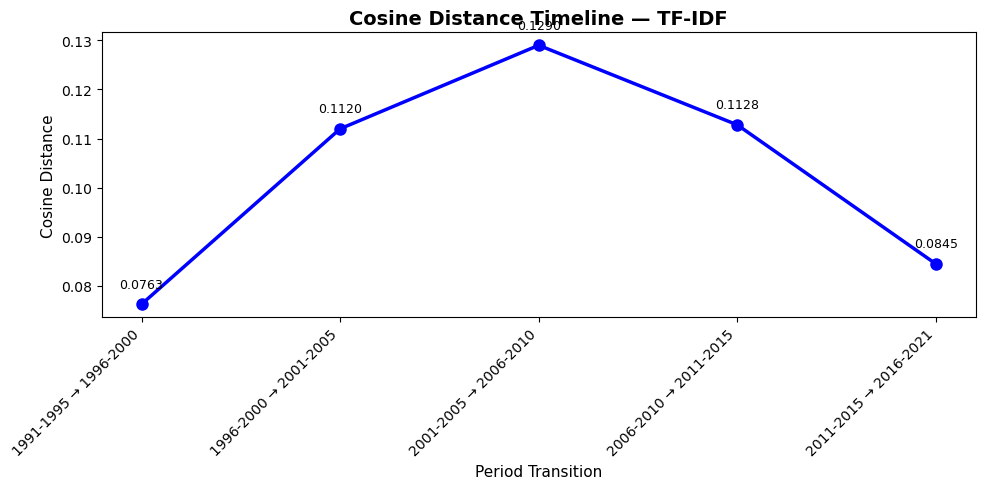

Saved: ../figures/cosine_distance_tfidf.png


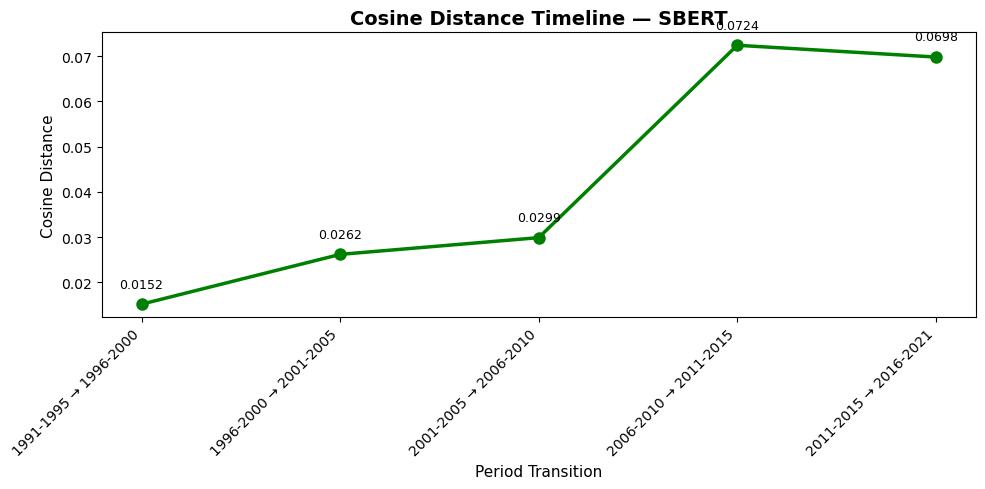

Saved: ../figures/cosine_distance_sbert.png


In [28]:
def plot_distance_timeline(df_dist, title, color, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(
        df_dist["transition"],
        df_dist["distance"],
        marker="o",
        linewidth=2.5,
        color=color,
        markersize=8
    )

    # Annotate each point with its distance value
    for _, row in df_dist.iterrows():
        plt.annotate(
            f"{row['distance']:.4f}",
            (row["transition"], row["distance"]),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9
        )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Period Transition", fontsize=11)
    plt.ylabel("Cosine Distance", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

# Plot TF-IDF timeline
plot_distance_timeline(
    tfidf_distances,
    "Cosine Distance Timeline — TF-IDF",
    color="blue",
    save_path="../figures/cosine_distance_tfidf.png"
)

# Plot SBERT timeline
plot_distance_timeline(
    sbert_distances,
    "Cosine Distance Timeline — SBERT",
    color="green",
    save_path="../figures/cosine_distance_sbert.png"
)

### TF-IDF vs SBERT Distance Comparison

Plotting both distance timelines on the same chart to directly compare 
whether TF-IDF and SBERT agree on when the biggest shifts occurred.

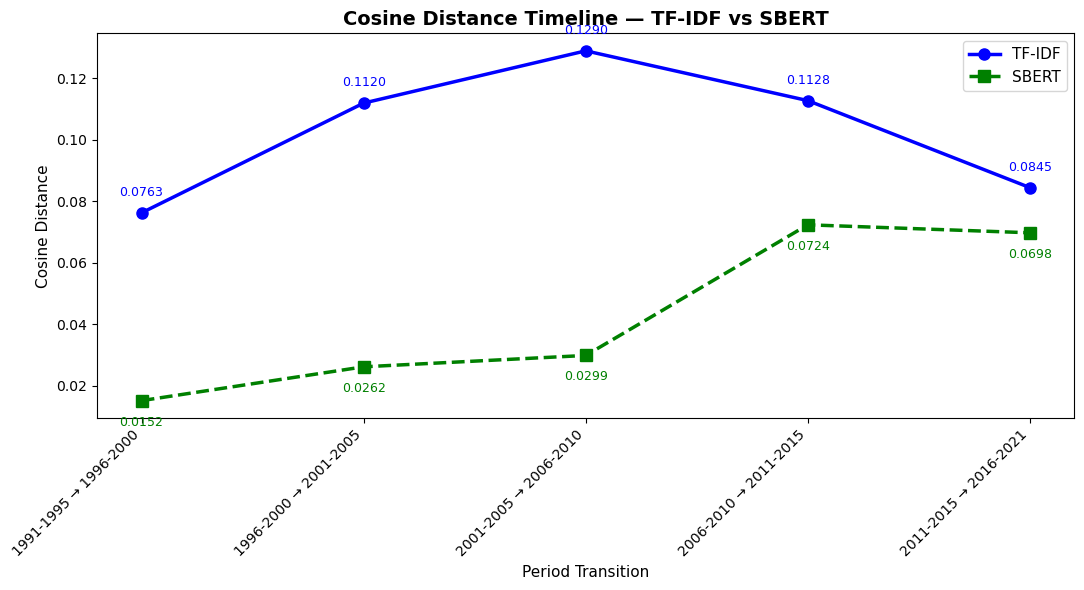

Saved: ../figures/cosine_distance_comparison.png


In [29]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    tfidf_distances["transition"],
    tfidf_distances["distance"],
    marker="o",
    linewidth=2.5,
    color="blue",
    label="TF-IDF",
    markersize=8
)

ax.plot(
    sbert_distances["transition"],
    sbert_distances["distance"],
    marker="s",
    linewidth=2.5,
    color="green",
    label="SBERT",
    markersize=8,
    linestyle="--"
)

# Annotate TF-IDF values
for _, row in tfidf_distances.iterrows():
    ax.annotate(
        f"{row['distance']:.4f}",
        (row["transition"], row["distance"]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=9,
        color="blue"
    )

# Annotate SBERT values
for _, row in sbert_distances.iterrows():
    ax.annotate(
        f"{row['distance']:.4f}",
        (row["transition"], row["distance"]),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center",
        fontsize=9,
        color="green"
    )

ax.set_title(
    "Cosine Distance Timeline — TF-IDF vs SBERT",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Period Transition", fontsize=11)
ax.set_ylabel("Cosine Distance", fontsize=11)
ax.legend(fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/cosine_distance_comparison.png", dpi=150)
plt.show()
print("Saved: ../figures/cosine_distance_comparison.png")

### Identifying Breakpoint Years

The period transition with the highest cosine distance is the 
breakpoint — the moment when NLP research changed most dramatically.

We identify the breakpoint for both TF-IDF and SBERT separately 
and check whether both methods agree.

In [31]:
# Find biggest shift for each method
tfidf_breakpoint = tfidf_distances.loc[tfidf_distances["distance"].idxmax()]
sbert_breakpoint = sbert_distances.loc[sbert_distances["distance"].idxmax()]

print("BREAKPOINT ANALYSIS")

print(f"\nTF-IDF biggest shift:")
print(f"  Transition : {tfidf_breakpoint['transition']}")
print(f"  Distance   : {tfidf_breakpoint['distance']}")

print(f"\nSBERT biggest shift:")
print(f"  Transition : {sbert_breakpoint['transition']}")
print(f"  Distance   : {sbert_breakpoint['distance']}")

# Check if both methods agree
if tfidf_breakpoint["transition"] == sbert_breakpoint["transition"]:
    print(f"Both methods AGREE")
    print(f"  Biggest shift at: {tfidf_breakpoint['transition']}")
else:
    print(f"Methods DISAGREE")
    print(f"  TF-IDF says: {tfidf_breakpoint['transition']}")
    print(f"  SBERT  says: {sbert_breakpoint['transition']}")

# Full ranking for both methods
print("\n--- TF-IDF distances ranked highest to lowest ---")
print(tfidf_distances[["transition","distance"]]
      .sort_values("distance", ascending=False)
      .to_string(index=False))

print("\n--- SBERT distances ranked highest to lowest ---")
print(sbert_distances[["transition","distance"]]
      .sort_values("distance", ascending=False)
      .to_string(index=False))

BREAKPOINT ANALYSIS

TF-IDF biggest shift:
  Transition : 2001-2005 → 2006-2010
  Distance   : 0.129

SBERT biggest shift:
  Transition : 2006-2010 → 2011-2015
  Distance   : 0.07240000367164612
Methods DISAGREE
  TF-IDF says: 2001-2005 → 2006-2010
  SBERT  says: 2006-2010 → 2011-2015

--- TF-IDF distances ranked highest to lowest ---
           transition  distance
2001-2005 → 2006-2010    0.1290
2006-2010 → 2011-2015    0.1128
1996-2000 → 2001-2005    0.1120
2011-2015 → 2016-2021    0.0845
1991-1995 → 1996-2000    0.0763

--- SBERT distances ranked highest to lowest ---
           transition  distance
2006-2010 → 2011-2015    0.0724
2011-2015 → 2016-2021    0.0698
2001-2005 → 2006-2010    0.0299
1996-2000 → 2001-2005    0.0262
1991-1995 → 1996-2000    0.0152


### Summary of Findings

#### Breakpoints Identified
| Method | Biggest Shift | Distance |
|---|---|---|
| TF-IDF | 2001-2005 → 2006-2010 | 0.1290 |
| SBERT  | 2006-2010 → 2011-2015 | 0.0724 |

#### Do Both Methods Agree?
No — TF-IDF and SBERT identify different breakpoint periods. 
This disagreement is itself a meaningful finding.

#### Why They Disagree
- **TF-IDF** measures surface vocabulary change — it detected that 
  the actual words used in abstracts changed most dramatically between 
  2001-2005 and 2006-2010. This aligns with the rise of statistical 
  machine learning methods entering NLP during this period, bringing 
  new terminology into the field.

- **SBERT** measures semantic meaning change — it detected that the 
  deeper conceptual focus of research shifted most between 2006-2010 
  and 2011-2015. This aligns with the deep learning revolution 
  entering NLP around 2012-2013, fundamentally changing what 
  researchers were working on.

#### Key Insight
The vocabulary changed BEFORE the meaning shifted. Researchers 
started adopting new words and phrases around 2006-2010 but the 
actual research focus did not fundamentally change until 2011-2015. 
This suggests a gradual transition rather than a sudden revolution.

#### SBERT Distances Are Consistently Smaller Than TF-IDF
- TF-IDF distances range from 0.076 to 0.129
- SBERT distances range from 0.015 to 0.072

This shows that while the vocabulary of NLP changed quite sharply 
at certain points, the underlying semantic meaning of research 
evolved more gradually over time.

#### Alignment With Known NLP History
| Period | Known Event | Detected by |
|---|---|---|
| 2001-2005 → 2006-2010 | Rise of statistical ML in NLP | TF-IDF  |
| 2006-2010 → 2011-2015 | Deep learning enters NLP (~2012) | SBERT |
| 2011-2015 → 2016-2021 | Transformer era (BERT 2018) | Both show continued shift |